In [5]:
#importing python classes and packages
import matplotlib.pyplot as plt
from tkinter.filedialog import askopenfilename
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
import seaborn as sns
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn import svm
from sklearn.linear_model import LogisticRegression
import shap
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
import lightgbm as lgb
import catboost as cb

In [6]:
#!pip install lightgbm

In [7]:
#load and display dataset values
dataset = pd.read_csv("Dataset/healthcare-dataset-stroke-data.csv")
dataset.fillna(0, inplace = True)
dataset

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,0.0,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,0.0,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


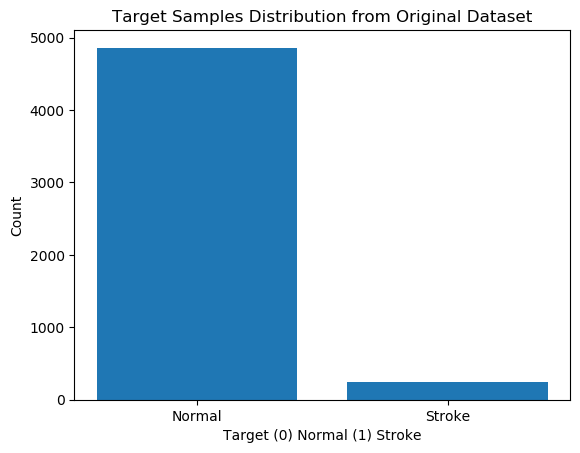

In [8]:
#finidng and plotting labels in dataset and in below graph we can see dataset is highly imbalance as one class contains
#so many instances and other contains very few instances and this imbalance we will handle using SMOTE
unique, count = np.unique(dataset['stroke'], return_counts = True)
labels = ['Normal', 'Stroke']
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Target (0) Normal (1) Stroke")
plt.ylabel("Count")
plt.title("Target Samples Distribution from Original Dataset")
plt.show()

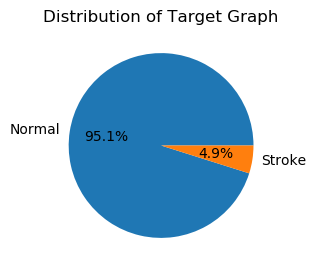

In [9]:
#graphs of different labels found in dataset
plt.figure(figsize=(3,3))
plt.pie(count, labels = labels, autopct='%.1f%%')
plt.title("Distribution of Target Graph")
plt.show() 

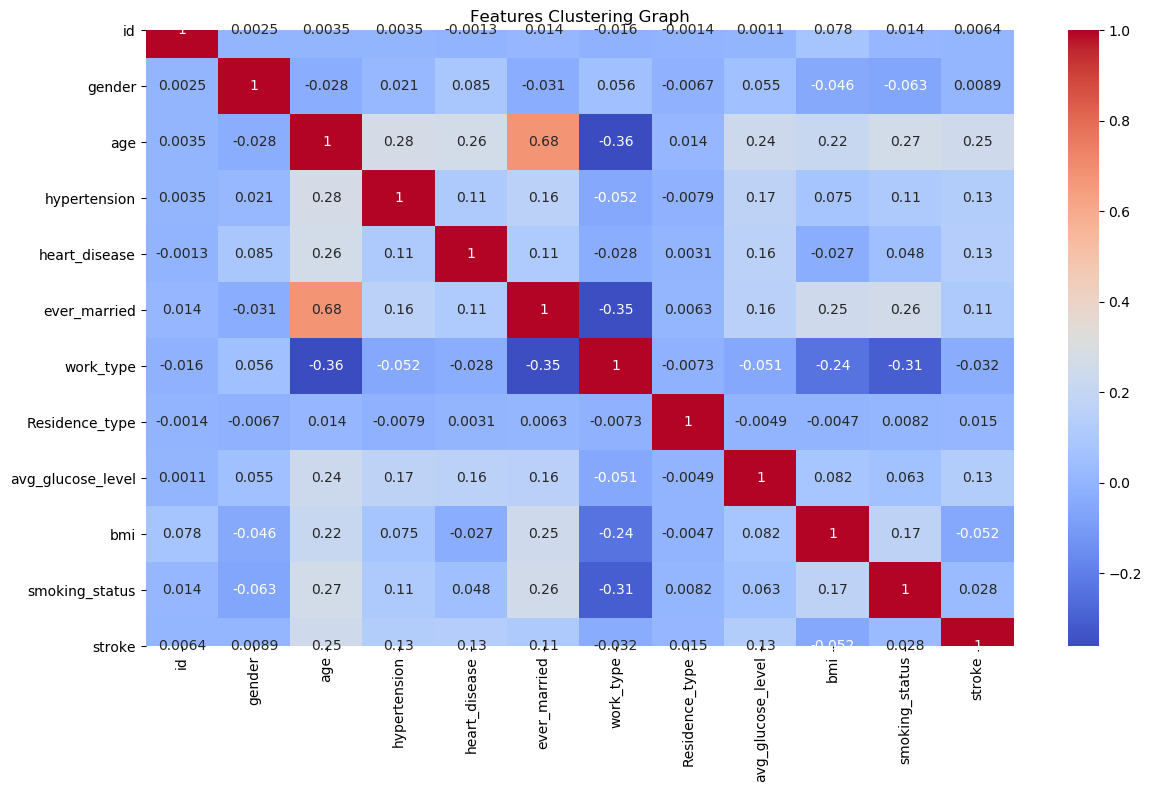

In [10]:

# Create a temporary copy of the dataset to convert categorical features for correlation calculation
dataset_numeric_corr = dataset.copy()

# Apply label encoding to relevant columns for correlation calculation
# Check if columns are still objects (strings) before encoding to avoid errors if already encoded
if 'gender' in dataset_numeric_corr.columns and dataset_numeric_corr['gender'].dtype == 'object':
    le_gender = LabelEncoder()
    dataset_numeric_corr['gender'] = le_gender.fit_transform(dataset_numeric_corr['gender'].astype(str))
if 'ever_married' in dataset_numeric_corr.columns and dataset_numeric_corr['ever_married'].dtype == 'object':
    le_married = LabelEncoder()
    dataset_numeric_corr['ever_married'] = le_married.fit_transform(dataset_numeric_corr['ever_married'].astype(str))
if 'work_type' in dataset_numeric_corr.columns and dataset_numeric_corr['work_type'].dtype == 'object':
    le_work = LabelEncoder()
    dataset_numeric_corr['work_type'] = le_work.fit_transform(dataset_numeric_corr['work_type'].astype(str))
if 'Residence_type' in dataset_numeric_corr.columns and dataset_numeric_corr['Residence_type'].dtype == 'object':
    le_residence = LabelEncoder()
    dataset_numeric_corr['Residence_type'] = le_residence.fit_transform(dataset_numeric_corr['Residence_type'].astype(str))
if 'smoking_status' in dataset_numeric_corr.columns and dataset_numeric_corr['smoking_status'].dtype == 'object':
    le_smoking = LabelEncoder()
    dataset_numeric_corr['smoking_status'] = le_smoking.fit_transform(dataset_numeric_corr['smoking_status'].astype(str))

plt.figure(figsize=(14,8))
sns.heatmap(dataset_numeric_corr.corr(), cmap='coolwarm', annot=True)
plt.title("Features Clustering Graph")
plt.show()

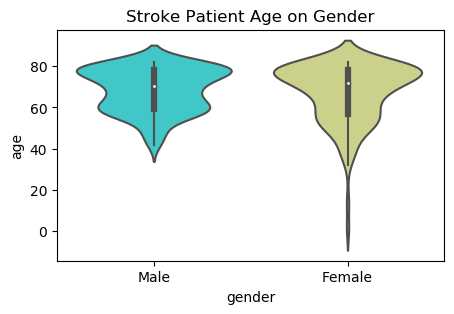

In [11]:
#plot graph of stroke patient based on age and gender
plt.figure(figsize=(5,3))
temp = dataset.loc[dataset['stroke'] == 1]
sns.violinplot(x='gender',y='age',data=temp,palette='rainbow')
plt.title("Stroke Patient Age on Gender")
plt.show()

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison


Text(0.5, 1.0, 'Age Distribution of Stroke Patients')

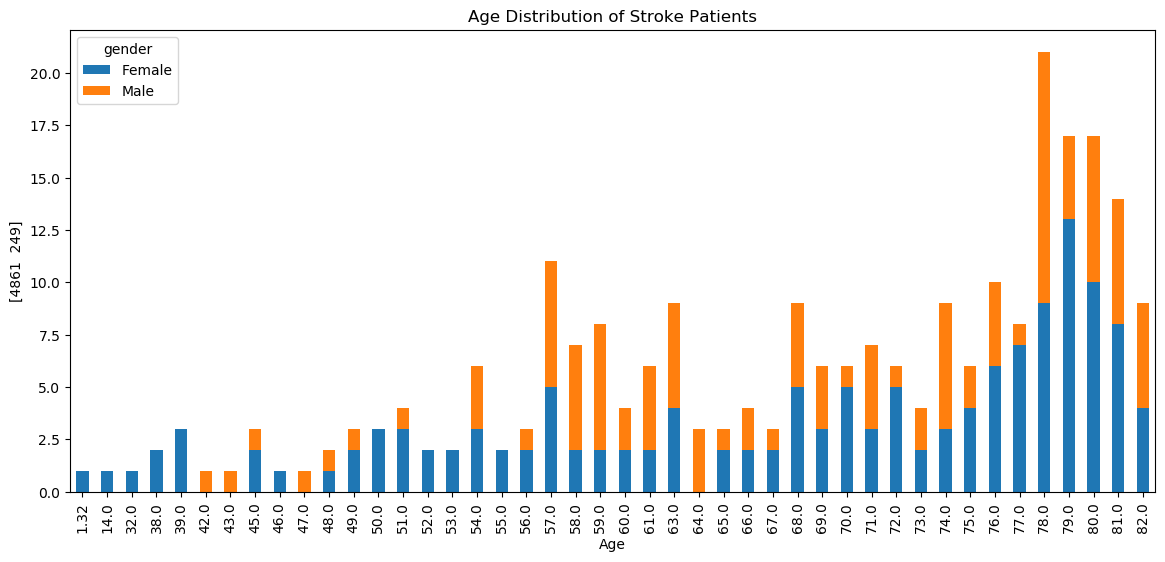

In [12]:
#plot graph of stroke patient based on age and gender in bar graph
data = temp[['age', 'gender']]
data.groupby(['age', 'gender']).size().unstack().plot(kind='bar', stacked=True, figsize=(14,6))
plt.xlabel("Age")
plt.ylabel(count)
plt.title("Age Distribution of Stroke Patients")

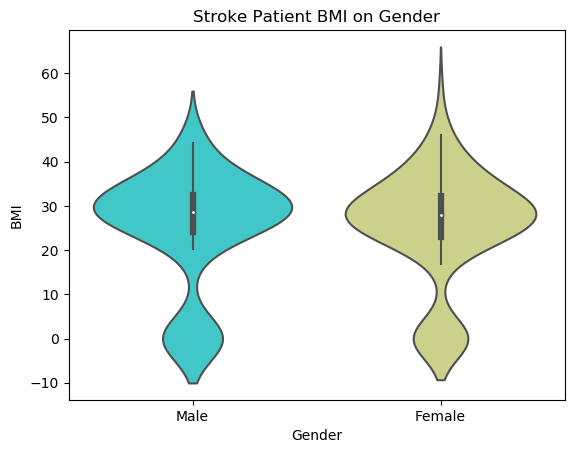

In [13]:
#graph of Stroke Patient using BMI on Gender
sns.violinplot(x='gender',y='bmi',data=temp,palette='rainbow')
plt.title("Stroke Patient BMI on Gender")
plt.xlabel("Gender")
plt.ylabel("BMI")
plt.show()

Text(0.5, 1.0, "Stroke Patient's Hypertension Status")

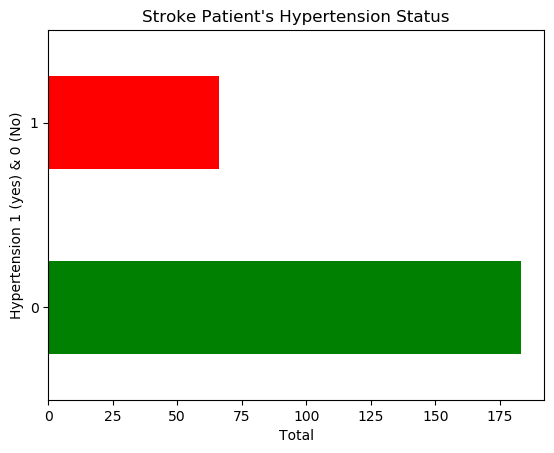

In [14]:
#finding and plotting graph in stroke patient suffering from hyper tension
data = temp[['hypertension']]
data.groupby(['hypertension']).size().plot(kind='barh', color=['g', 'r'])
plt.xlabel("Total")
plt.ylabel("Hypertension 1 (yes) & 0 (No)")
plt.title("Stroke Patient's Hypertension Status")

Text(0.5, 1.0, "Stroke Patient's Heart Disease")

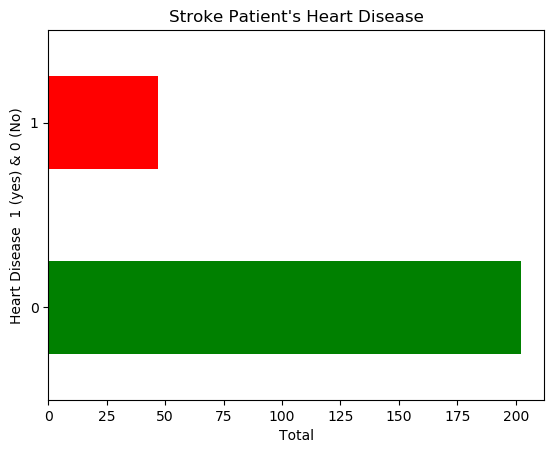

In [15]:
#finding and plotting graph in stroke patient suffering from heart disease
data = temp[['heart_disease']]
data.groupby(['heart_disease']).size().plot(kind='barh', color=['g', 'r'])
plt.xlabel("Total")
plt.ylabel("Heart Disease  1 (yes) & 0 (No)")
plt.title("Stroke Patient's Heart Disease")

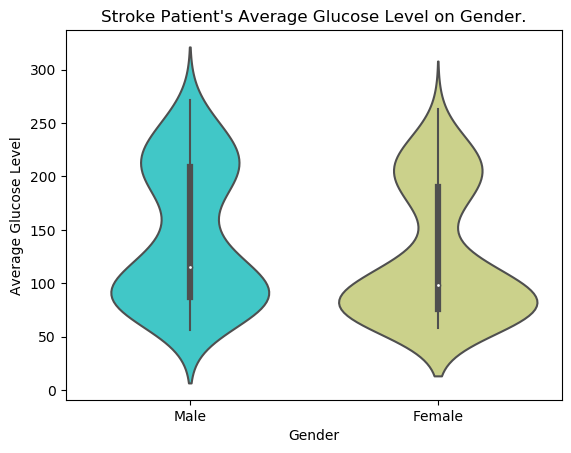

In [16]:
#finding and plotting graph in stroke patient with average glucose level
sns.violinplot(x='gender',y='avg_glucose_level',data=temp,palette='rainbow')
plt.title("Stroke Patient's Average Glucose Level on Gender.")
plt.xlabel("Gender")
plt.ylabel("Average Glucose Level")
plt.show()

Text(0.5, 1.0, "Stroke Patient's Smoking Status")

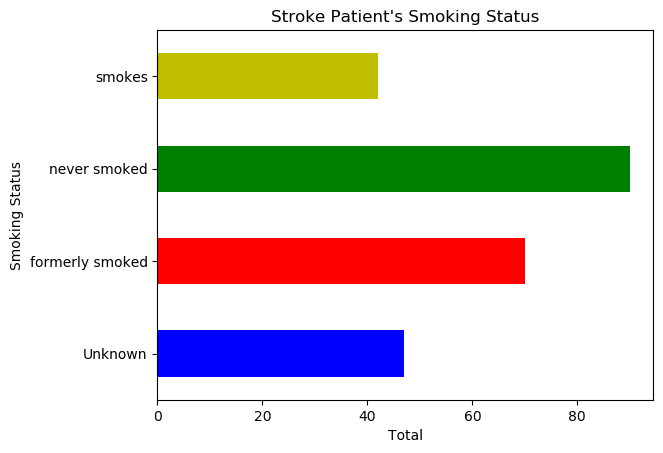

In [17]:
#finding and plotting graph in stroke patient doing smoking
data = temp[['smoking_status']]
data.groupby(['smoking_status']).size().plot(kind='barh', color=['b', 'r', 'g', 'y'])
plt.xlabel("Total")
plt.ylabel("Smoking Status")
plt.title("Stroke Patient's Smoking Status")

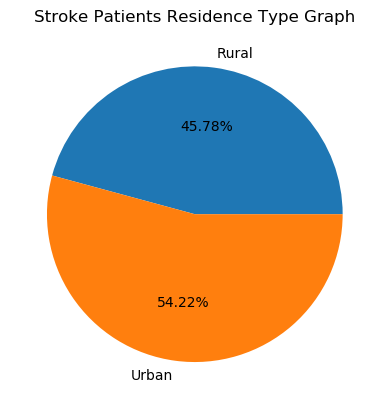

In [18]:
#finding and plotting graph of stroke patient using residence type
unique, count = np.unique(temp['Residence_type'], return_counts=True)
plt.pie(count, labels = unique, autopct='%1.2f%%')
plt.title("Stroke Patients Residence Type Graph")
plt.show()

In [19]:
#convert categorical (non-numeric data) into numeric format using label encoder class
encoder1 = LabelEncoder()
encoder2 = LabelEncoder()
encoder3 = LabelEncoder()
encoder4 = LabelEncoder()
encoder5 = LabelEncoder()
dataset['gender'] = pd.Series(encoder1.fit_transform(dataset['gender'].astype(str)))#encode all str columns to numeric
dataset['ever_married'] = pd.Series(encoder2.fit_transform(dataset['ever_married'].astype(str)))#encode all str columns to numeric
dataset['work_type'] = pd.Series(encoder3.fit_transform(dataset['work_type'].astype(str)))
dataset['Residence_type'] = pd.Series(encoder4.fit_transform(dataset['Residence_type'].astype(str)))
dataset['smoking_status'] = pd.Series(encoder5.fit_transform(dataset['smoking_status'].astype(str)))
dataset

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,51676,0,61.0,0,0,1,3,0,202.21,0.0,2,1
2,31112,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,60182,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,1665,0,79.0,1,0,1,3,0,174.12,24.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,0,80.0,1,0,1,2,1,83.75,0.0,2,0
5106,44873,0,81.0,0,0,1,3,1,125.20,40.0,2,0
5107,19723,0,35.0,0,0,1,3,0,82.99,30.6,2,0
5108,37544,1,51.0,0,0,1,2,0,166.29,25.6,1,0


In [20]:
# Reload the dataset to ensure 'stroke' column is always present
dataset = pd.read_csv("Dataset/healthcare-dataset-stroke-data.csv")
dataset.fillna(0, inplace = True)

# Re-initialize and refit the encoders on the reloaded dataset to ensure all labels are known
# This makes the encoding step robust against inconsistent global encoder states or kernel restarts
encoder1 = LabelEncoder()
encoder2 = LabelEncoder()
encoder3 = LabelEncoder()
encoder4 = LabelEncoder()
encoder5 = LabelEncoder()

encoder1.fit(dataset['gender'].astype(str))
dataset['gender'] = pd.Series(encoder1.transform(dataset['gender'].astype(str)))

encoder2.fit(dataset['ever_married'].astype(str))
dataset['ever_married'] = pd.Series(encoder2.transform(dataset['ever_married'].astype(str)))

encoder3.fit(dataset['work_type'].astype(str))
dataset['work_type'] = pd.Series(encoder3.transform(dataset['work_type'].astype(str)))

encoder4.fit(dataset['Residence_type'].astype(str))
dataset['Residence_type'] = pd.Series(encoder4.transform(dataset['Residence_type'].astype(str)))

encoder5.fit(dataset['smoking_status'].astype(str))
dataset['smoking_status'] = pd.Series(encoder5.transform(dataset['smoking_status'].astype(str)))

# Extract Y target label
Y = dataset['stroke'].to_numpy()

# Drop ID column and then 'stroke' to get X training features (operate on a copy)
X_features = dataset.drop(['id', 'stroke'], axis = 1)
X = X_features.values

# Normalized dataset features
sc1 = MinMaxScaler(feature_range = (0, 1))
X = sc1.fit_transform(X)#features normalization
print(f"Normalize Features : {X.shape}")

Normalize Features : (5110, 10)


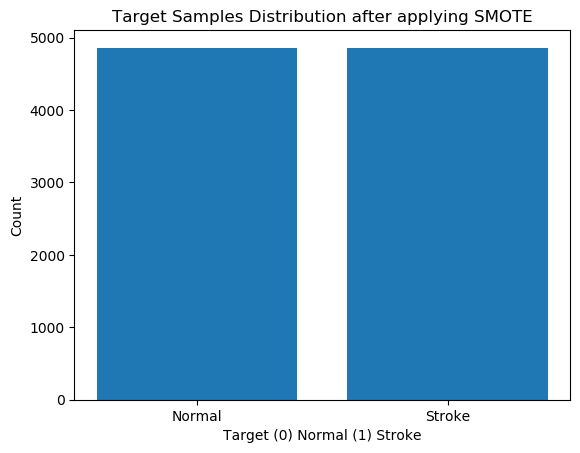

In [21]:
#now apply Smote to balance dataset
sm = SMOTE()
X, Y = sm.fit_resample(X, Y)
unique, count = np.unique(Y, return_counts=True)
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Target (0) Normal (1) Stroke")
plt.ylabel("Count")
plt.title("Target Samples Distribution after applying SMOTE")
plt.show()

In [22]:
#now select features uisng CHI Square features selection algorithm
print("Features available in dataset before selection : "+str(X.shape[1]))
features_selector = SelectKBest(score_func=chi2, k = 9)
selected_features = features_selector.fit_transform(X, Y)
print("Features available in dataset after selection : "+str(selected_features.shape[1]))

Features available in dataset before selection : 10
Features available in dataset after selection : 9


In [23]:
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(selected_features, Y, test_size=0.2) #split dataset into train and test
print()
print("Dataset train & test split as 80% dataset for training and 20% for testing")
print(f"Training Size (80%): {X_train.shape[0]}") #print training and test size
print(f"Testing Size (20%): {X_test.shape[0]}")
print()


Dataset train & test split as 80% dataset for training and 20% for testing
Training Size (80%): 7777
Testing Size (20%): 1945



In [24]:
#define global variables to calculate and store accuracy and other metrics
precision = []
recall = []
fscore = []
accuracy = []

In [25]:
#function to calculate various metrics such as accuracy, precision etc
def calculateMetrics(algorithm, predict, testY):
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100
    print()
    print(f'{algorithm} Accuracy  : {a}')
    print(f'{algorithm} Precision   : {p}')
    print(f'{algorithm} Recall      : {r}')
    print(f'{algorithm} FMeasure    : {f}')
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    labels = unique
    conf_matrix = confusion_matrix(testY, predict)
    plt.figure(figsize =(5, 5))
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix")
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    plt.show()


Random Forest Accuracy  : 93.62467866323907
Random Forest Precision   : 93.6098104652294
Random Forest Recall      : 93.68223819954328
Random Forest FMeasure    : 93.62062982195532


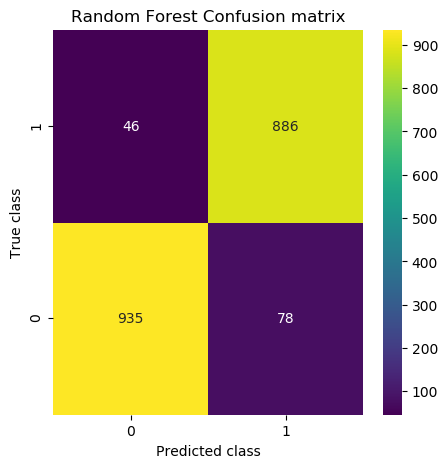

In [26]:
#train random forest algorithm on training dataset and test its prediction capability on test data
#now train Random Forest algorithm
rf_cls = RandomForestClassifier()
rf_cls.fit(X_train, y_train)
predict = rf_cls.predict(X_test)
calculateMetrics("Random Forest", predict, y_test)


Logistic Regression Accuracy  : 79.48586118251927
Logistic Regression Precision   : 79.74252800339757
Logistic Regression Recall      : 79.67114210541925
Logistic Regression FMeasure    : 79.48323626895254


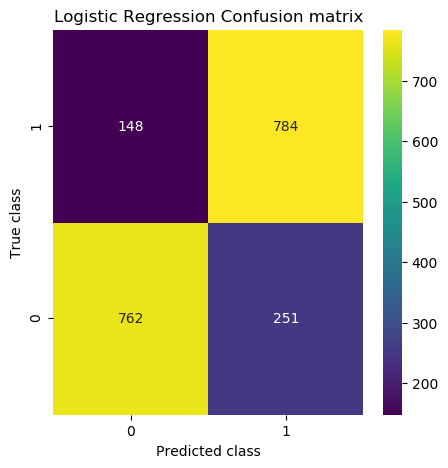

In [27]:
#now train LogisticRegression algorithm
lr_cls = LogisticRegression()#define regression object
lr_cls.fit(X_train, y_train)#train regression on training data
predict = lr_cls.predict(X_test)#perform prediction on test data
calculateMetrics("Logistic Regression", predict, y_test)#calculate accuracy and other metrics


SVM Accuracy  : 81.13110539845758
SVM Precision   : 82.05488154766785
SVM Recall      : 81.47796457215003
SVM FMeasure    : 81.0850257657449


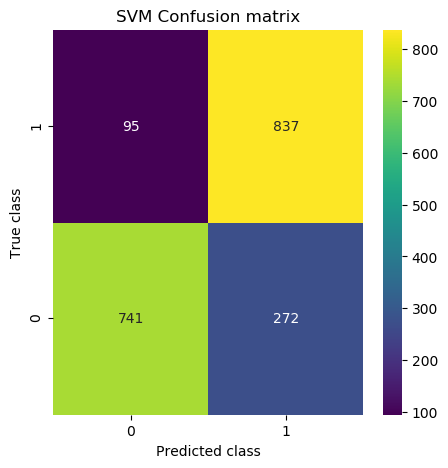

In [28]:
#now train SVM algorithm
svm_cls = svm.SVC()#define SVM object
svm_cls.fit(X_train, y_train)#train SVM on training data
predict = svm_cls.predict(X_test)#perform prediction on test data
calculateMetrics("SVM", predict, y_test)#calculate accuracy and other metrics


KNN Accuracy  : 90.38560411311055
KNN Precision   : 90.73437088232043
KNN Recall      : 90.60269077104932
KNN FMeasure    : 90.38361119769999


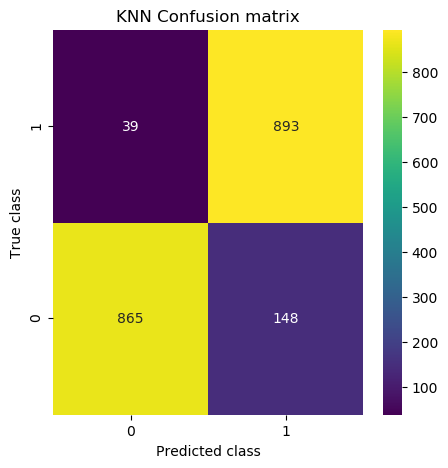

In [29]:
#now train KNN algorithm
knn_cls =  KNeighborsClassifier(n_neighbors=3)#define KNN object
knn_cls.fit(X_train, y_train)#train KNN on training data
predict = knn_cls.predict(X_test)#perform prediction on test data
calculateMetrics("KNN", predict, y_test)#calculate accuracy and other metrics


Naive Bayes Accuracy  : 76.91516709511568
Naive Bayes Precision   : 77.1065747613998
Naive Bayes Recall      : 77.07453321413894
Naive Bayes FMeasure    : 76.91428834266793


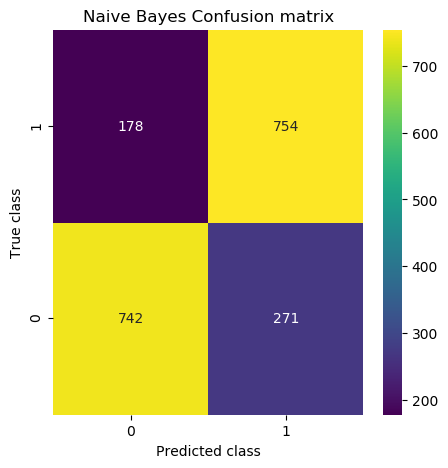

In [30]:
#now train Naive Bayes algorithm
nb_cls =  GaussianNB()#define Naive Bayes object
nb_cls.fit(X_train, y_train)#train Naive Bayes on training data
predict = nb_cls.predict(X_test)#perform prediction on test data
calculateMetrics("Naive Bayes", predict, y_test)#calculate accuracy and other metrics


XGBoost Accuracy  : 88.58611825192803
XGBoost Precision   : 88.81814922992403
XGBoost Recall      : 88.76790563871388
XGBoost FMeasure    : 88.58560833402065


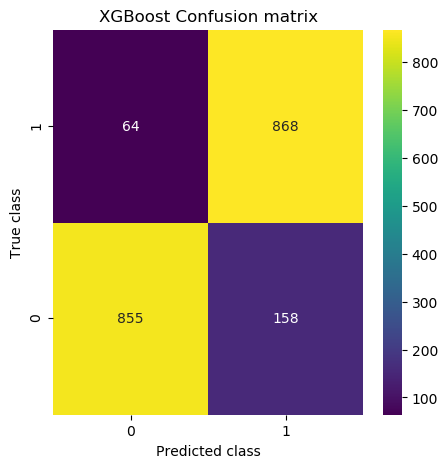

In [31]:
#now train XGBoost algorithm
xg_cls =  XGBClassifier(n_estimators=10)#define XGBOOST object
xg_cls.fit(X_train, y_train)#train XGBOost on training data
predict = xg_cls.predict(X_test)#perform prediction on test data
calculateMetrics("XGBoost", predict, y_test)#calculate accuracy and other metrics

[LightGBM] [Info] Number of positive: 3929, number of negative: 3848
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1329
[LightGBM] [Info] Number of data points in the train set: 7777, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.505208 -> initscore=0.020831
[LightGBM] [Info] Start training from score 0.020831

LightGBM Accuracy  : 94.34447300771208
LightGBM Precision   : 94.3867185509757
LightGBM Recall      : 94.29175016629313
LightGBM FMeasure    : 94.32918153616495


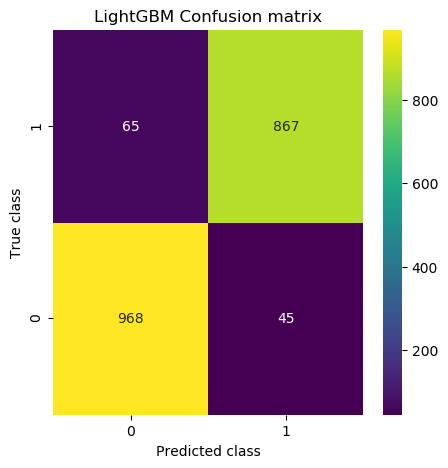

In [32]:
#now train LightGBM algorithm
lgb_cls = lgb.LGBMClassifier(objective='binary', num_leaves=31, learning_rate=0.05, n_estimators=100)
lgb_cls.fit(X_train, y_train)#train LightGBM on training data
predict = lgb_cls.predict(X_test)#perform prediction on test data
calculateMetrics("LightGBM", predict, y_test)#calculate accuracy and other metrics

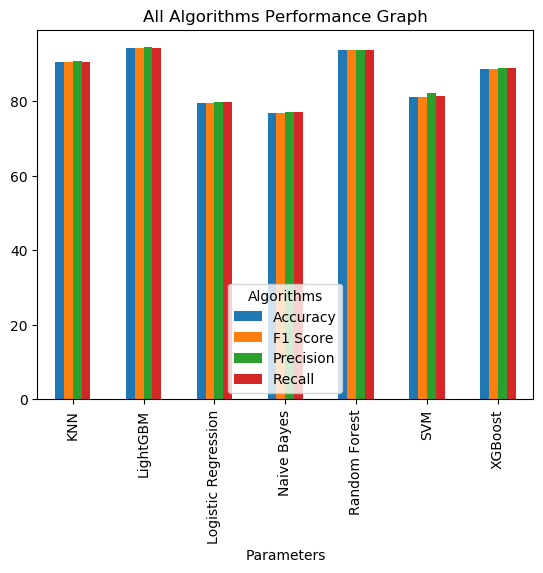

In [33]:
#plot comparison between all algortihms
df = pd.DataFrame([['Random Forest','Precision',precision[0]],['Random Forest','Recall',recall[0]],['Random Forest','F1 Score',fscore[0]],['Random Forest','Accuracy',accuracy[0]],
                   ['Logistic Regression','Precision',precision[1]],['Logistic Regression','Recall',recall[1]],['Logistic Regression','F1 Score',fscore[1]],['Logistic Regression','Accuracy',accuracy[1]],
                   ['SVM','Precision',precision[2]],['SVM','Recall',recall[2]],['SVM','F1 Score',fscore[2]],['SVM','Accuracy',accuracy[2]],
                   ['KNN','Precision',precision[3]],['KNN','Recall',recall[3]],['KNN','F1 Score',fscore[3]],['KNN','Accuracy',accuracy[3]],
                   ['Naive Bayes','Precision',precision[4]],['Naive Bayes','Recall',recall[4]],['Naive Bayes','F1 Score',fscore[4]],['Naive Bayes','Accuracy',accuracy[4]],
                   ['XGBoost','Precision',precision[5]],['XGBoost','Recall',recall[5]],['XGBoost','F1 Score',fscore[5]],['XGBoost','Accuracy',accuracy[5]],
                   ['LightGBM','Precision',precision[6]],['LightGBM','Recall',recall[6]],['LightGBM','F1 Score',fscore[6]],['LightGBM','Accuracy',accuracy[6]]
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot(index="Parameters", columns="Algorithms", values="Value").plot(kind='bar')
plt.title("All Algorithms Performance Graph")
plt.show()

In [34]:
#showing all algorithms with scenario A and B performance values
columns = ["Algorithm Name","Precison","Recall","FScore","Accuracy"]
values = []
algorithm_names = ["Random Forest","Logistic Regression", "SVM", "KNN", "Naive Bayes", "XGBOost", "LightGBM"]
for i in range(len(algorithm_names)):
    values.append([algorithm_names[i],precision[i],recall[i],fscore[i],accuracy[i]])

temp = pd.DataFrame(values,columns=columns)
temp

,Algorithm Name,Precison,Recall,FScore,Accuracy
0,Random Forest,93.609810,93.682238,93.620630,93.624679
1,Logistic Regression,79.742528,79.671142,79.483236,79.485861
2,SVM,82.054882,81.477965,81.085026,81.131105
3,KNN,90.734371,90.602691,90.383611,90.385604
4,Naive Bayes,77.106575,77.074533,76.914288,76.915167
5,XGBOost,88.818149,88.767906,88.585608,88.586118
6,LightGBM,94.386719,94.291750,94.329182,94.344473


In [35]:
testData = pd.read_csv("Dataset/testData.csv")#reading test data
testData.fillna(0, inplace = True)
temp = testData.values
testData['gender'] = pd.Series(encoder1.transform(testData['gender'].astype(str)))#converting non-numeric data to numeric
testData['ever_married'] = pd.Series(encoder2.transform(testData['ever_married'].astype(str)))
testData['work_type'] = pd.Series(encoder3.transform(testData['work_type'].astype(str)))
testData['Residence_type'] = pd.Series(encoder4.transform(testData['Residence_type'].astype(str)))
testData['smoking_status'] = pd.Series(encoder5.transform(testData['smoking_status'].astype(str)))
testData.drop(['id'], axis=1, inplace=True)#drop id column
testData = testData.values
test = sc1.transform(testData)#normalizing values
test = features_selector.transform(test)#select relevant features using CHI2 selector
predict = lgb_cls.predict(test)#performing prediction on test data using LightGBM
for i in range(len(predict)):
    print(f"Test Data = {temp[i]} Predicted As ====> {labels[predict[i]]}\n")

Test Data = [4559 'Male' 38.0 0 0 'No' 'Private' 'Rural' 86.86 36.5 'Unknown'] Predicted As ====> Normal

Test Data = [45357 'Female' 1.24 0 0 'No' 'children' 'Rural' 113.96 21.5 'Unknown'] Predicted As ====> Normal

Test Data = [8213 'Male' 78.0 0 1 'Yes' 'Private' 'Urban' 219.84 0.0 'Unknown'] Predicted As ====> Stroke

Test Data = [27419 'Female' 59.0 0 0 'Yes' 'Private' 'Rural' 76.15 0.0 'Unknown'] Predicted As ====> Normal

Test Data = [60491 'Female' 78.0 0 0 'Yes' 'Private' 'Urban' 58.57 24.2 'Unknown'] Predicted As ====> Normal

Test Data = [12109 'Female' 81.0 1 0 'Yes' 'Private' 'Rural' 80.43 29.7 'never smoked'] Predicted As ====> Normal

Test Data = [5317 'Female' 79.0 0 1 'Yes' 'Private' 'Urban' 214.09 28.2 'never smoked'] Predicted As ====> Stroke

Test Data = [58202 'Female' 50.0 1 0 'Yes' 'Self-employed' 'Rural' 167.41 30.9
 'never smoked'] Predicted As ====> Normal

Test Data = [45257 'Female' 38.0 0 0 'Yes' 'Private' 'Rural' 81.28 33.2 'smokes'] Predicted As ====> Nor